## Fine tuning DeepSeek 1.5B model using LoRA technique for dialogue summarization dataset

### Loading libraries

In [1]:
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, TrainingArguments, Trainer
import torch
import time
import evaluate
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

















### Load Dataset and LLM

You are going to continue experimenting with the [DialogSum](https://huggingface.co/datasets/knkarthick/dialogsum) Hugging Face dataset. It contains 10,000+ dialogues with the corresponding manually labeled summaries and topics. 

In [2]:
huggingface_dataset_name = "knkarthick/dialogsum"

dataset = load_dataset(huggingface_dataset_name)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})

### Loading the model

In [3]:
model_name='deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B'

original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)


In [4]:
def model_parameters(model):
    trainable_model_params = 0
    all_model_params = 0
    for _, param in model.named_parameters():
        all_model_params += param.numel()
        if param.requires_grad:
            trainable_model_params += param.numel()
    return trainable_model_params

print(f"the number of trainable parameters in the original model: {model_parameters(original_model)}")

the number of trainable parameters in the original model: 1777088000


### Test the Model before fine-tuning


In [5]:
# index = 200

# dialogue = dataset['test'][index]['dialogue']
# summary = dataset['test'][index]['summary']

# prompt = f"""
# Summarize the following conversation.

# {dialogue}

# Summary:
# """

# inputs = tokenizer(prompt, return_tensors='pt')
# output = tokenizer.decode(
#     original_model.generate(
#         inputs["input_ids"], 
#         max_new_tokens=200,
#     )[0], 
#     skip_special_tokens=True
# )

# print(f'Input prompt:{prompt}')
# print(f'\n\n Human summary: \n{summary}\n')
# print(f'\n\nOriginal model summarization before fine-tuning: \n\n{output}')

Model max length for DeepSeek 1.5B: 16384

Combined (Dialogue + Summary) Lengths:
Max: 1549, Min: 72
Mean: 238.01, Median: 217.0
95th Percentile: 429.00
99th Percentile: 623.82


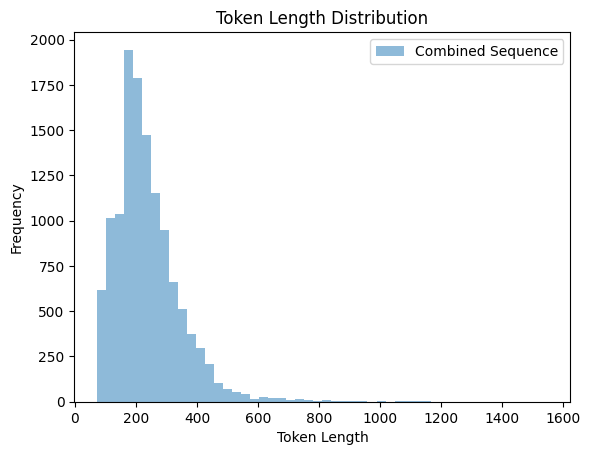

In [6]:
tokenizer.truncation_side = "right"  
tokenizer.padding_side = "right"     
print(f"Model max length for DeepSeek 1.5B: {tokenizer.model_max_length}")  

# Function to compute token lengths without padding/truncation
def get_token_lengths(example):
    start_prompt = 'Summarize the following conversation:\n\n'
    end_prompt = '\n\nSummary: '
    # Combine dialogue and summary as in your tokenize_function
    combined = start_prompt + example["dialogue"] + end_prompt + example["summary"]
    combined_tokens = tokenizer(combined, truncation=False, padding=False).input_ids
    return {"combined_length": len(combined_tokens)}

# Apply to the 'train' split 
lengths_dataset = dataset["train"].map(get_token_lengths, batched=False)

# Collect lengths
combined_lengths = lengths_dataset["combined_length"]

# Compute statistics
def print_stats(lengths, name):
    print(f"\n{name} Lengths:")
    print(f"Max: {max(lengths)}, Min: {min(lengths)}")
    print(f"Mean: {np.mean(lengths):.2f}, Median: {np.median(lengths)}")
    print(f"95th Percentile: {np.percentile(lengths, 95):.2f}")
    print(f"99th Percentile: {np.percentile(lengths, 99):.2f}")

print_stats(combined_lengths, "Combined (Dialogue + Summary)")

# Visualize distribution
plt.hist(combined_lengths, bins=50, alpha=0.5, label="Combined Sequence")
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.legend()
plt.title("Token Length Distribution")
plt.show()

In [8]:
# Suggest optimal max_length
max_combined_length = min(int(np.percentile(combined_lengths, 95)), tokenizer.model_max_length)
print(f"\nSuggested max_length for combined sequence (input_ids/labels): {max_combined_length}")

# tokenize_function 
def tokenize_function(example):
    tokenizer.truncation_side = "right"  # Truncate from the right
    tokenizer.padding_side = "right"     # Pad on the right
    start_prompt = 'Summarize the following conversation:\n\n'
    end_prompt = '\n\nSummary: '
    
    # Combine dialogue and summary in a single sequence
    prompt = [start_prompt + dialogue + end_prompt + summary 
              for dialogue, summary in zip(example["dialogue"], example["summary"])]
    
    # Tokenize input sequence (dialogue + summary)
    tokenized = tokenizer(
        prompt, 
        padding="max_length", 
        truncation=True, 
        max_length=512, 
        return_tensors="pt"
    )
    
    # Labels: Clone input_ids, padding tokens are handled by the model during training
    tokenized['labels'] = tokenized['input_ids'].clone()
    
    return tokenized

# Apply tokenization
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Remove unnecessary columns
tokenized_datasets = tokenized_datasets.remove_columns(['id', 'topic', 'dialogue', 'summary'])


Suggested max_length for combined sequence (input_ids/labels): 429


Map: 100%|█████████████████████████| 1500/1500 [00:00<00:00, 4937.87 examples/s]


In [9]:
print(tokenized_datasets)
print(tokenized_datasets['train'][0])


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1500
    })
})
{'input_ids': [151646, 9190, 5612, 551, 279, 2701, 10435, 1447, 2, 10680, 16, 48082, 21018, 11, 4392, 13, 9082, 13, 358, 2776, 18635, 69587, 13, 8429, 525, 498, 1588, 3351, 5267, 2, 10680, 17, 48082, 358, 1730, 432, 1035, 387, 264, 1661, 4522, 311, 633, 264, 1779, 5239, 624, 2, 10680, 16, 48082, 7414, 11, 1632, 11, 498, 8990, 944, 1030, 825, 369, 220, 20, 1635, 13, 1446, 1265, 614, 825, 1449, 1042, 624, 2, 10680, 17, 48082, 358, 1414, 13, 358, 7071, 438, 1293, 438, 1052, 374, 4302, 4969, 11, 3170, 728, 1490, 279, 10668, 5267, 2, 10680, 16, 48082, 8325, 11, 279, 1850, 1616, 311, 5648, 6001, 48809, 374, 311, 1477, 700, 911, 1105, 4124, 1


## Perform Parameter Efficient Fine-Tuning (PEFT)

Now, let's perform **Parameter Efficient Fine-Tuning (PEFT)** fine-tuning as opposed to "full fine-tuning" as you did above. PEFT is a form of instruction fine-tuning that is much more efficient than full fine-tuning - with comparable evaluation results as you will see soon. 

PEFT is a generic term that includes **Low-Rank Adaptation (LoRA)** and prompt tuning (which is NOT THE SAME as prompt engineering!). In most cases, when someone says PEFT, they typically mean LoRA. LoRA, at a very high level, allows the user to fine-tune their model using fewer compute resources (in some cases, a single GPU). After fine-tuning for a specific task, use case, or tenant with LoRA, the result is that the original LLM remains unchanged and a newly-trained “LoRA adapter” emerges. This LoRA adapter is much, much smaller than the original LLM - on the order of a single-digit % of the original LLM size (MBs vs GBs).  

That said, at inference time, the LoRA adapter needs to be reunited and combined with its original LLM to serve the inference request.  The benefit, however, is that many LoRA adapters can re-use the original LLM which reduces overall memory requirements when serving multiple tasks and use cases.


###  Setup the PEFT/LoRA model for Fine-Tuning

You need to set up the PEFT/LoRA model for fine-tuning with a new layer/parameter adapter. Using PEFT/LoRA, you are freezing the underlying LLM and only training the adapter. Have a look at the LoRA configuration below. Note the rank (`r`) hyper-parameter, which defines the rank/dimension of the adapter to be trained.

In [10]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=64, # Rank
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

Add LoRA adapter layers/parameters to the original LLM to be trained.

In [11]:
peft_model = get_peft_model(original_model, 
                            lora_config)
peft_model.print_trainable_parameters()

trainable params: 8,716,288 || all params: 1,785,804,288 || trainable%: 0.4881


<a name='3.2'></a>
### 3.2 - Train PEFT Adapter

Define training arguments and create `Trainer` instance.

In [12]:
output_dir = "Fine_tuning_DeepSeek_1.5B_model_LoRA_summerization_512"

peft_training_args = TrainingArguments(
    output_dir=f'{output_dir}/model',
    logging_dir=f'{output_dir}/logs',

    auto_find_batch_size=True,
    learning_rate=1e-5, # Higher learning rate than full fine-tuning.
    lr_scheduler_type="cosine",    
    num_train_epochs=40,
    warmup_steps=200,
    #label_smoothing_factor=0.1,
    weight_decay=0.01,
    #logging_steps=1,
    #max_steps=1,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    optim="paged_adamw_8bit",


    # Evaluation & Logging
    evaluation_strategy="steps",
    eval_steps=1000,  
    save_steps=1000,
    logging_strategy="steps",
    logging_steps=10,  
    save_total_limit=2,
)
    
peft_trainer = Trainer(
    model=peft_model,
    args=peft_training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"]
)

/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [13]:
peft_trainer.train()

/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss
1000,0.508200,0.987041
2000,0.462200,0.955528
3000,0.465000,0.921042
4000,0.437800,0.911772
5000,0.456900,0.905734
6000,0.471100,0.901822
7000,0.453800,0.898854
8000,0.421600,0.896921
9000,0.449600,0.895336
10000,0.454400,0.894222


/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return

TrainOutput(global_step=15560, training_loss=0.49381166901870377, metrics={'train_runtime': 49731.7399, 'train_samples_per_second': 10.022, 'train_steps_per_second': 0.313, 'total_flos': 2.3708938583251354e+18, 'train_loss': 0.49381166901870377, 'epoch': 39.89887640449438})

In [14]:
# Save the model
save_dir = f'{output_dir}/final'

peft_trainer.save_model(save_dir)

tokenizer.save_pretrained(save_dir)

print(f"Final model saved to: {save_dir}")

Final model saved to: Fine_tuning_DeepSeek_1.5B_model_LoRA_summerization_test3/final


In [15]:
# peft_trainer.train()

# peft_model_path="./peft-dialogue-summary-checkpoint-local"

# peft_trainer.model.save_pretrained(peft_model_path)
# tokenizer.save_pretrained(peft_model_path)

In [16]:

model_name='deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B'

original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)


In [17]:
from peft import PeftModel, PeftConfig
save_dir = f'{output_dir}/final'

peft_model_base = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

#instruct_model = AutoModelForSeq2SeqLM.from_pretrained(save_dir, local_files_only=True)
peft_model = PeftModel.from_pretrained(peft_model_base, 
                                       save_dir, 
                                       torch_dtype=torch.bfloat16,
                                       is_trainable=False)
peft_model = peft_model.merge_and_unload()


In [18]:
# Check if LoRA adapters are applied
print(f"Active adapters: {peft_model.active_adapters}")


Active adapters: <bound method PeftAdapterMixin.active_adapters of Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    

<a name='3.3'></a>
### 3.3 - Evaluate the Model Qualitatively (Human Evaluation)

Make inferences for the same example as in sections [1.3](#1.3) and [2.3](#2.3), with the original model, fully fine-tuned and PEFT model.

In [21]:
def inference(text, model, tokenizer, max_input_tokens=1024, max_output_tokens=512):
    # Tokenize input
    input_ids = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_tokens
    )["input_ids"].to(model.device)

    # Generate response
    with torch.no_grad():
        generated_tokens = model.generate(
            input_ids=input_ids,
            max_length=max_output_tokens,  
            pad_token_id=tokenizer.eos_token_id  
        )

    # Decode and strip input prompt
    generated_text = tokenizer.decode(generated_tokens[0][input_ids.shape[1]:], skip_special_tokens=True)
    

    return generated_text


In [23]:
index = 1
dialogue = dataset['test'][index]['dialogue']
human_baseline_summary = dataset['test'][index]['summary']

prompt = f"""
Summarize the following conversation.

{dialogue}


Summary: 
"""


original_model_text_output = inference(prompt,original_model, tokenizer )
peft_model_text_output = inference(prompt,peft_model, tokenizer )

print(f'BASELINE HUMAN SUMMARY:\n{human_baseline_summary}')
print(f'ORIGINAL MODEL:\n{original_model_text_output}')
print(f'PEFT MODEL:\n{peft_model_text_output}')

BASELINE HUMAN SUMMARY:
In order to prevent employees from wasting time on Instant Message programs, #Person1# decides to terminate the use of those programs and asks Ms. Dawson to send out a memo to all employees by the afternoon.
ORIGINAL MODEL:
The summary should include the main points of the conversation, including the specific actions taken by both persons, the policies discussed, the consequences of actions, and the timing of the memo distribution. The summary should be concise and clear, avoiding unnecessary details.
</think>

The conversation outlines a policy change requiring employees to take dictation and distribute an intra-office memo. The memo is due by 4 pm. Key points include the memo's purpose, the policies on communication methods (email, memos, Instant Messaging), consequences for non-compliance, and the department heads' role in enforcing the policy.
PEFT MODEL:
Ms. Dawson asks #Person1# to take a dictation for her. #Person1# tells her that all office communication


### Evaluate the Model Quantitatively (with ROUGE Metric)

The [ROUGE metric](https://en.wikipedia.org/wiki/ROUGE_(metric)) helps quantify the validity of summarizations produced by models. It compares summarizations to a "baseline" summary which is usually created by a human. While not perfect, it does indicate the overall increase in summarization effectiveness that we have accomplished by fine-tuning.

In [24]:
rouge = evaluate.load('rouge')

Generate the outputs for the sample of the test dataset (only 10 dialogues and summaries to save time), and save the results.

In [25]:
import pandas as pd
import torch
from transformers import GenerationConfig

# Extract dialogues and human summaries
dialogues = dataset['test'][1100:1200]['dialogue']
human_baseline_summaries = dataset['test'][1100:1200]['summary']

# Lists to store generated summaries
original_model_summaries = []
peft_model_summaries = []

for idx, dialogue in enumerate(dialogues):
    # Define the causal generation prompt
    prompt = f"""
Summarize the following conversation.

{dialogue}

Summary: """  # The model should continue from this point

    # Tokenize input sequence
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids # Move to GPU if available

    # Human-written summary (baseline)
    human_baseline_text_output = human_baseline_summaries[idx]

    # Generate output using the original model
    original_model_outputs = original_model.generate(
        input_ids=input_ids, 
        generation_config=GenerationConfig(max_new_tokens=200)  # Ensure it generates only the summary
    )
    original_model_text_output = tokenizer.decode(original_model_outputs[0][input_ids.shape[1]:], skip_special_tokens=True)

    # Generate output using the PEFT fine-tuned model
    peft_model_outputs = peft_model.generate(
        input_ids=input_ids, 
        generation_config=GenerationConfig(max_new_tokens=200)
    )
    peft_model_text_output = tokenizer.decode(peft_model_outputs[0][input_ids.shape[1]:], skip_special_tokens=True)

    # Store results
    original_model_summaries.append(original_model_text_output)
    peft_model_summaries.append(peft_model_text_output)

# Create DataFrame for analysis
zipped_summaries = list(zip(human_baseline_summaries, original_model_summaries, peft_model_summaries))
df = pd.DataFrame(zipped_summaries, columns=['human_baseline_summaries', 'original_model_summaries', 'peft_model_summaries'])

df


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end gene

,human_baseline_summaries,original_model_summaries,peft_model_summaries
0,#Person2# asks #Person1# about a new service a...,1. The person is asking about a new service in...,#Person2# received some leaflets from #Person...
1,#Person1# would like to store his luggage in #...,"30 minutes left, place your luggage in the sto...",#Person1# wants to hit a few more places in t...
2,"#Person1# wants to hit some place, but he hesi...","30 minutes left, place your luggage in the sto...",#Person1# wants to hit a few more places in t...
3,#Person1# wants to hit some place. So he needs...,"30 minutes left, place your luggage in the sto...",#Person1# wants to hit a few more places in t...
4,#Person1# wants to know the charge at #Person2...,"#Person1#: #Person2#: \n\nAlright, I need to ...",#Person1# asks #Person2# to pay for the buffet.
...,...,...,...
95,#Person2# asks his daughter about admission re...,"#Person1#: #Person2#: \n\nAlright, so I need ...",#Person1# asks #Person2# about the admission ...
96,#Person2# wants to know admission requirement ...,"#Person1#: #Person2#: \n\nAlright, so I need ...",#Person1# asks #Person2# about the admission ...
97,Kalina calls Professor Clark that she needs to...,"#Person1#: Good morning, may I speak with Pro...",#Person1# calls Professor Clark to inform him...
98,Kalina calls Professor Clark and asks for leav...,"#Person1#: Good morning, may I speak with Pro...",#Person1# calls Professor Clark to inform him...


In [51]:
print(df.iloc[0,0])
print(df.iloc[0,1])
print(df.iloc[0,2])

#Person2# asks #Person1# about a new service and additional benefits as a stock investor. #Person1# can provide an online tailored consultation service.
1. The person is asking about a new service introduced by the bank. 2. They are interested in additional benefits for stock investors. 3. They want to know if they can use the service remotely without visiting the branch.

Now, I need to create a summary that captures all these points in a concise manner, using the same structure as the original conversation.
</think>

The conversation highlights the introduction of a new financial service by the bank, its popularity, and the availability of tailored consultation services. The person inquires about the service and its benefits, particularly for stock investors, and seeks assistance in using the service remotely. The summary captures these key points in a structured format.
 #Person2# received some leaflets from #Person1# and asks for more information about the new service. #Person1# te

#### Compute ROUGE score for this subset of the data. 

In [26]:
rouge = evaluate.load('rouge')

original_model_results = rouge.compute(
    predictions=original_model_summaries,
    references=human_baseline_summaries[0:len(original_model_summaries)],
    use_aggregator=True,
    use_stemmer=True,
)

peft_model_results = rouge.compute(
    predictions=peft_model_summaries,
    references=human_baseline_summaries[0:len(peft_model_summaries)],
    use_aggregator=True,
    use_stemmer=True,
)

print('ORIGINAL MODEL:')
print(original_model_results)

print('PEFT MODEL:')
print(peft_model_results)

ORIGINAL MODEL:
{'rouge1': np.float64(0.14531908612479125), 'rouge2': np.float64(0.042002414127601084), 'rougeL': np.float64(0.103568484406619), 'rougeLsum': np.float64(0.11992575003469633)}
PEFT MODEL:
{'rouge1': np.float64(0.42424524410973535), 'rouge2': np.float64(0.13952864255598083), 'rougeL': np.float64(0.3212076879656708), 'rougeLsum': np.float64(0.32098454705184754)}
